###**Q1. Gradient diffusions.**

Let's consider the SDE in $\mathbb{R}$ defined by

$$
dX_t = - \nabla U(X_t) \, dt + dW_t
$$

where $U(x)$ is a smooth function, called the potential, $\sigma$ is the noise amplitude (real, positive), and $W_t$ is a $d$-dimensional Brownian motion. Assume that $U(x)$ is convex (U-shaped), and so has a unique minimum at some point $x^*$. Assume also that $X_t$ is ergodic, so there exists a unique stationary distribution $p$.


####(a) **Consider the noise-free SDE by setting (σ = 0). What is the long-term behavior of the corresponding ODE?**

By setting the noise amplitude $\sigma = 0$, the SDE reduces to the following ODE:

$$
\frac{dX_t}{dt} = - U(X_t)
$$

Since the potential function \(U(x)\) is convex and smooth, as $t \to \infty$, the trajectory $X_t$ converges to the unique global minimum $x^*$ of $U(x)$. Mathematically:

$$
\lim_{t \to \infty} X_t = x^*, \quad \text{where} \quad x^* = \arg \min_x U(x)
$$



####**(b) Given the stationary distribution**

The stationary distribution is given by:

$$
p^*(x) = c \, e^{-2U(x)/\sigma^2}
$$

Discuss the shape of $p^*$ with respect to $x^*$. Where does $p^*$ concentrate when $\sigma \to 0$?

Shape of $p^*$: The distribution $p^*(x)$ is a Gibbs distribution. The probability density function $p^*(x)$ is maximal where the exponent $-2U(x)/\sigma^2$ is maximal. Therefore, the peak of the distribution is located exactly at $x^*$. The density decreases exponentially as we move away from $x^*$.

Concentration when $\sigma \to 0$: When the noise disappears ($\sigma \to 0$), the stationary distribution $p^*$ converges to a Dirac delta measure centered on the global minimum $x^*$, in accordance with Laplace's principle:

$$
\lim_{\sigma \to 0} p^*(x) = \delta(x - x^*)
$$


### **Q2. Stochastic gradient descent.**

In [403]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import networkx as nx
from scipy.integrate import odeint

#### (a) **Let's find numerically the positions of the local and global minima of U(x) using any routine or function in Python.**

In [404]:
def U(x):
    return 0.5*x**4 - 5*x**2 + x
def dU(x):
    return 2*x**3 - 10*x + 1
def d2U(x):
    return 6*x**2 - 10


# Here we are trying to define bounds that could contain the maximum and minimum values.
initial_guesses = [-50, -20, -5, 0, 5, 20, 50]
crit_points = [fsolve(dU, x0)[0] for x0 in initial_guesses]

crit_points = np.unique(np.round(crit_points, 6))
U_values = U(crit_points)

# filter only the minimums
minima = []
minima_values = []
for x, u in zip(crit_points, U_values):
    if d2U(x) > 0:
        minima.append(x)
        minima_values.append(u)

# To specify the global minimum
global_min_index = np.argmin(minima_values)
global_min = minima[global_min_index]
local_mins = [float(x) for i, x in enumerate(minima) if i != global_min_index]
print(f"The global minimum is at x ≈ {global_min}")
print(f"The other local minima are at x ≈ {local_mins}")


The global minimum is at x ≈ -2.284484
The other local minima are at x ≈ [2.184283]


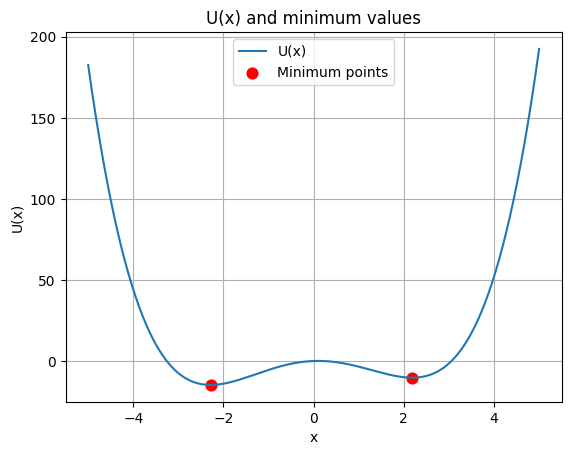

In [405]:

U_minima = U(np.array(minima))
x_plot = np.linspace(-5, 5, 500)
plt.plot(x_plot, U(x_plot), label="U(x)")
# To mark critical points
plt.scatter(minima, U_minima, color="red", s=60, label="Minimum points")
plt.title("U(x) and minimum values")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.legend()
plt.grid(True)
plt.show()

#### **(b) Solve the gradient descent dynamics, defined by the ODE**

x0 = -4 -> Converged value: -2.28448, U(x) = -14.76053
x0 = -1 -> Converged value: -2.28448, U(x) = -14.76053
x0 = 0.1 -> Converged value: -2.28448, U(x) = -14.76053
x0 = 2 -> Converged value: 2.18428, U(x) = -10.28952
x0 = 4 -> Converged value: 2.18428, U(x) = -10.28952


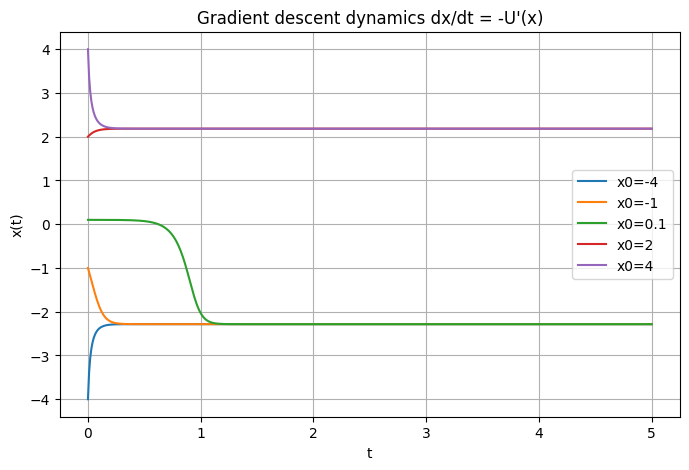

In [406]:
def ode_function(x, t):
    return -dU(x)

tfinal = 5
dt = 0.01
n = int(tfinal/dt)
t = np.linspace(0, tfinal, n)

initial_conditions = [-4, -1, 0.1, 2, 4]

plt.figure(figsize=(8,5))


for x0 in initial_conditions:
    sol = odeint(ode_function, x0, t)
    plt.plot(t, sol, label=f"x0={x0}")
    print(f"x0 = {x0} -> Converged value: {sol[-1, 0]:.5f}, U(x) = {U(sol[-1, 0]):.5f}")

# plt.axhline(y=global_min, color='r', linestyle='--', label=f'Minima x-coord ({global_min:.2f})')
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Gradient descent dynamics dx/dt = -U'(x)")
plt.grid(True)
plt.legend()
plt.show()

**Analyse :**
Each trajectory converges to a local minimum or the global minimum, depending on its initial condition. The results show that:

* Initial conditions x0 = -4, -1, 0.1 all converge to the value x ≈ -2.28448 with U(x) ≈ -14.76053.

* Initial conditions x0 = 2, 4 converge to x ≈ 2.18428 with U(x) ≈ -10.28952.

Comparing the values ​​of U(x) at the endpoints:

* U(-2.28448) = -14.76053 is smaller than U(2.18428) = -10.28952.

The global minimum of U(x) is at x ≈ -2.28448, while x ≈ 2.18428 corresponds to a local minimum.

The gradient descent ODE converges to the minimum closest to the initial condition, and comparing the final values ​​of U(x) allows us to identify the global minimum.

#### (c) **Solve the stochastic gradient descent dynamics, defined by the SDE**.

In [407]:
def simulate_em(x0, T, dt, sigma):
    n_steps = int(T / dt) + 1
    t = np.linspace(0, T, n_steps)
    X = np.zeros(n_steps)
    X[0] = x0
    sqrt_dt = np.sqrt(dt)
    for i in range(1, n_steps):
        dW = sqrt_dt * np.random.randn()
        X[i] = X[i-1] - dU(X[i-1]) * dt + sigma * dW
    return t, X



--- Experiment: T=10, σ=1.0 
x0 = -4 -> final X = -2.29569, U(X) = -14.75919
x0 = -1 -> final X = -2.66202, U(X) = -12.98561
x0 = 0.1 -> final X = -2.35042, U(X) = -14.71289
x0 = 2 -> final X = 2.43011, U(X) = -9.65996
x0 = 4 -> final X = 2.27340, U(X) = -10.21243

--- Experiment: T=100, σ=2.5 
x0 = -4 -> final X = -1.97075, U(X) = -13.84787
x0 = -1 -> final X = -1.96355, U(X) = -13.80866
x0 = 0.1 -> final X = -2.65126, U(X) = -13.09250
x0 = 2 -> final X = 1.88650, U(X) = -9.57509
x0 = 4 -> final X = -2.73292, U(X) = -12.18529


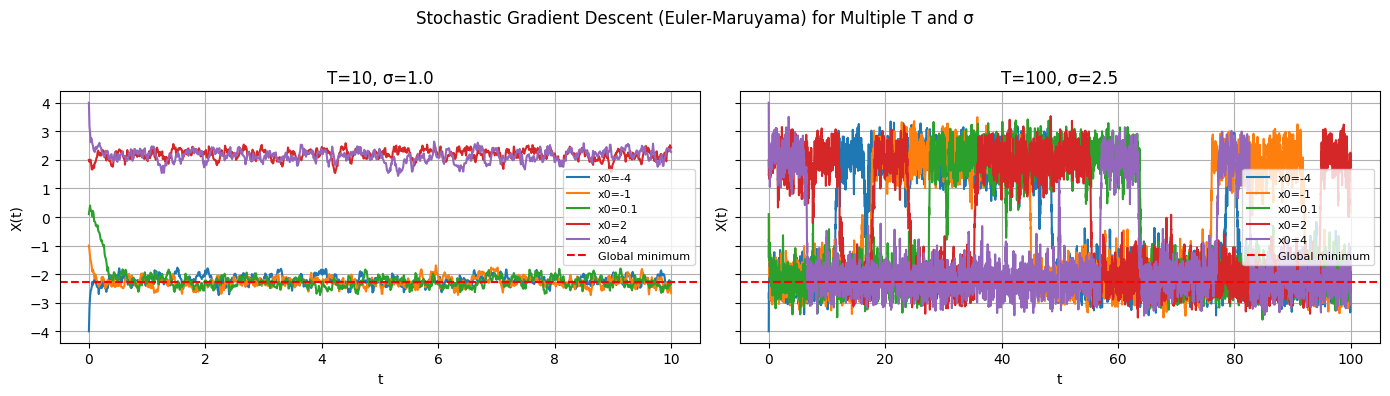

In [408]:
experiments = [
    {"T": 10.0, "sigma": 1.0,  "label": "T=10, σ=1.0"},
    {"T": 100.0, "sigma": 2.5, "label": "T=100, σ=2.5"},
]

fig, axes = plt.subplots(1, len(experiments), figsize=(14, 4), sharey=True)

global_min = global_min

for ax, exp in zip(axes, experiments):
    T = exp["T"]
    sigma = exp["sigma"]
    print(f"\n--- Experiment: {exp['label']} ")
    for x0 in initial_conditions:
        t, X = simulate_em(x0, T, dt, sigma)
        ax.plot(t, X, label=f"x0={x0}")
        print(f"x0 = {x0} -> final X = {X[-1]:.5f}, U(X) = {U(X[-1]):.5f}")
    ax.axhline(global_min, color='red', linestyle='--', label='Global minimum')
    ax.set_title(exp["label"])
    ax.set_xlabel("t")
    ax.set_ylabel("X(t)")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.suptitle("Stochastic Gradient Descent (Euler-Maruyama) for Multiple T and σ")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### (d) **Repeat part (c), but now decrease the noise in time according to $\sigma_{t}$**


--- Experiment: T=10, alpha=5.0 ---
x0 = -4 -> final X = -2.30097, U(X) = -14.75762
x0 = -1 -> final X = -2.28573, U(X) = -14.76052
x0 = 0.1 -> final X = 2.22836, U(X) = -10.27105
x0 = 2 -> final X = -2.22088, U(X) = -14.71859
x0 = 4 -> final X = 2.09409, U(X) = -10.21693

--- Experiment: T=20, alpha=5.0 ---
x0 = -4 -> final X = -2.27479, U(X) = -14.75953
x0 = -1 -> final X = -2.34348, U(X) = -14.72249
x0 = 0.1 -> final X = 2.19456, U(X) = -10.28853
x0 = 2 -> final X = -2.33549, U(X) = -14.73220
x0 = 4 -> final X = 2.19185, U(X) = -10.28898

--- Experiment: T=40, alpha=5.0 ---
x0 = -4 -> final X = 2.18226, U(X) = -10.28948
x0 = -1 -> final X = -2.28430, U(X) = -14.76053
x0 = 0.1 -> final X = -2.28174, U(X) = -14.76045
x0 = 2 -> final X = -2.25936, U(X) = -14.75388
x0 = 4 -> final X = 2.16724, U(X) = -10.28683

--- Experiment: T=50, alpha=5.0 ---
x0 = -4 -> final X = 2.15881, U(X) = -10.28355
x0 = -1 -> final X = -2.26378, U(X) = -14.75601
x0 = 0.1 -> final X = 2.19350, U(X) = -10.2887

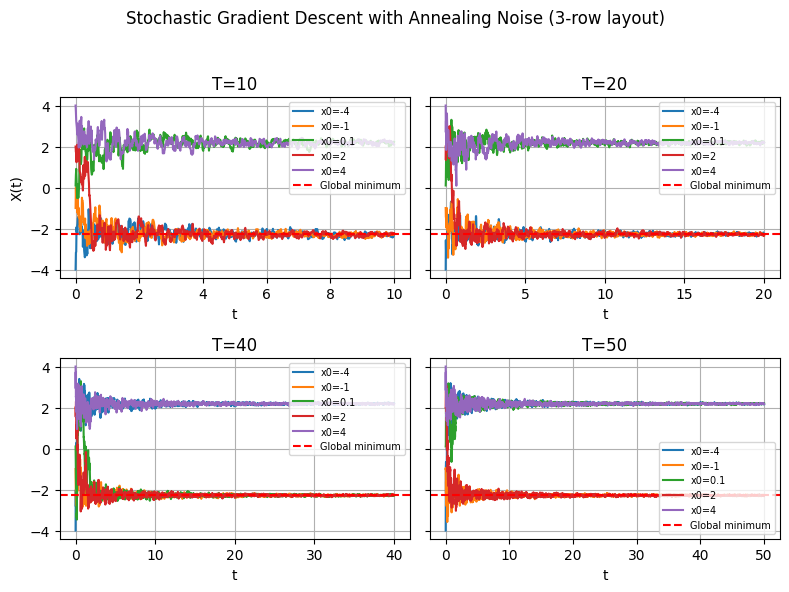

In [409]:
T_values = [10,20,40,50]
alpha=5.0


def simulate_em_annealing(x0, T, dt, alpha=5.0):
    n_steps = int(np.ceil(T / dt)) + 1
    t = np.linspace(0, T, n_steps)
    X = np.zeros(n_steps)
    X[0] = x0
    sqrt_dt = np.sqrt(dt)
    for i in range(1, n_steps):
        sigma_t = alpha / (i*dt + 1)
        dW = sqrt_dt * np.random.randn()
        X[i] = X[i-1] - dU(X[i-1]) * dt + sigma_t * dW
    return t, X


n_rows = 2
n_cols = int(np.ceil(len(T_values)/n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharey=True)
axes = axes.flatten()

for ax, T in zip(axes, T_values):
    print(f"\n--- Experiment: T={T}, alpha={alpha} ---")
    for x0 in initial_conditions:
        t, X = simulate_em_annealing(x0, T, dt, alpha=alpha)
        ax.plot(t, X, label=f"x0={x0}")
        print(f"x0 = {x0} -> final X = {X[-1]:.5f}, U(X) = {U(X[-1]):.5f}")
    ax.axhline(global_min, color='red', linestyle='--', label='Global minimum')
    ax.set_title(f"T={T}")
    ax.set_xlabel("t")
    ax.grid(True)
    if ax==axes[0]:
        ax.set_ylabel("X(t)")
    ax.legend(fontsize=7)


plt.suptitle("Stochastic Gradient Descent with Annealing Noise (3-row layout)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


####**(e) What is the advantage of stochastic gradient descent over deterministic gradient descent.**

We can conclude that stochastic gradient descent prioritizes speed and exploration over precision and avoids getting stuck in poor local minima.

## **Q3. Simulated annealing.**

### **(a) Let's find the global minimum of V(x) on IR? No calculations required.**


$$
V(x) = x^2 \left(2 + (\sin(10x))^{2} \right)
$$

Let's notice that $x^2 \ge 0$ always. The factor $(2 + (\sin(10x))^{2})$ oscillates but is always positive.
Therefore, the is the global minimum is at $x=0$, where $V(0) = 0$.



### **(b) Use the Metropolis algorithm with simulated annealing to locate the global minimum of V(x)**

In [410]:
def V(x):
    return x**2 * (2 + np.sin(10*x))**2

def simulated_annealing(V, n_steps, step_distribution, proposal_scale):
    X = np.zeros(n_steps)
    X[0] = np.random.uniform(-10, 10)
    accept = 0
    for n in range(1, n_steps):
        beta = 1 + np.log(n+1)
        x_curr = X[n-1]
        x_prop = x_curr + step_distribution(proposal_scale)
        dV = V(x_prop) - V(x_curr)
        exponent = -beta * dV
        # to avoid ovewflow
        if exponent < -700:
            alpha = 0
        else:
            alpha = min(1, np.exp(exponent))
        if np.random.rand() < alpha:
            X[n] = x_prop
            accept += 1
        else:
            X[n] = x_curr
    return X, accept / n_steps



Proposal scale: 0.5
Estimated global minimum: x ≈ 0.015946, V(x) ≈ 0.001185
Proposal scale: 5
Estimated global minimum: x ≈ -0.032478, V(x) ≈ 0.002980


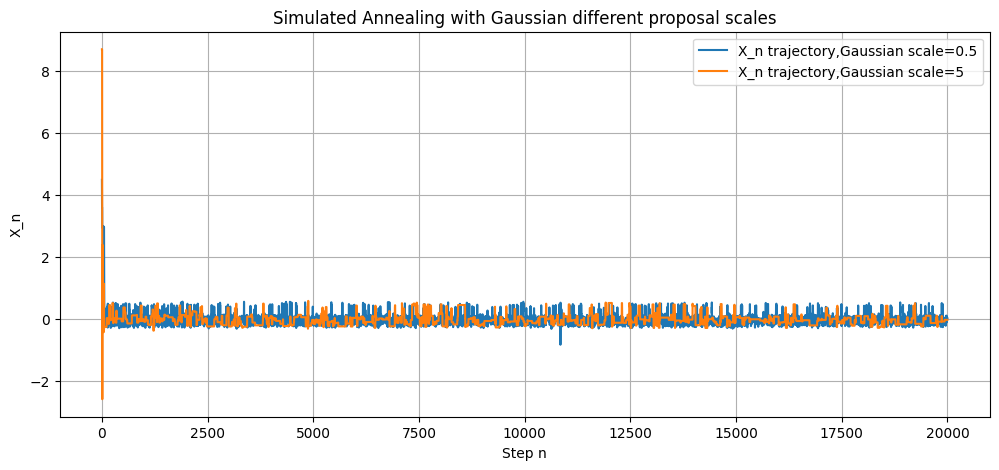

In [444]:
def step_gaussian(scale):
    return scale * np.random.randn()
n_steps = 20000
proposal_scales = [0.5, 5]

plt.figure(figsize=(12,5))

for scale in proposal_scales:
    X_traj, accept_rate = simulated_annealing(V, n_steps, step_gaussian, scale)
    x_min = X_traj[-1]
    V_min = V(x_min)
    print(f"Proposal scale: {scale}")
    print(f"Estimated global minimum: x ≈ {x_min:.6f}, V(x) ≈ {V_min:.6f}")
    plt.plot(np.arange(n_steps), X_traj, label=f"X_n trajectory,Gaussian scale={scale}")

plt.xlabel("Step n")
plt.ylabel("X_n")
plt.title("Simulated Annealing with Gaussian different proposal scales")
plt.grid(True)
plt.legend()
plt.show()

Uniform proposal scale: 5
Estimated global minimum: x ≈ -0.084354, V(x) ≈ 0.011172
Uniform proposal scale: 10
Estimated global minimum: x ≈ 0.048425, V(x) ≈ 0.014255


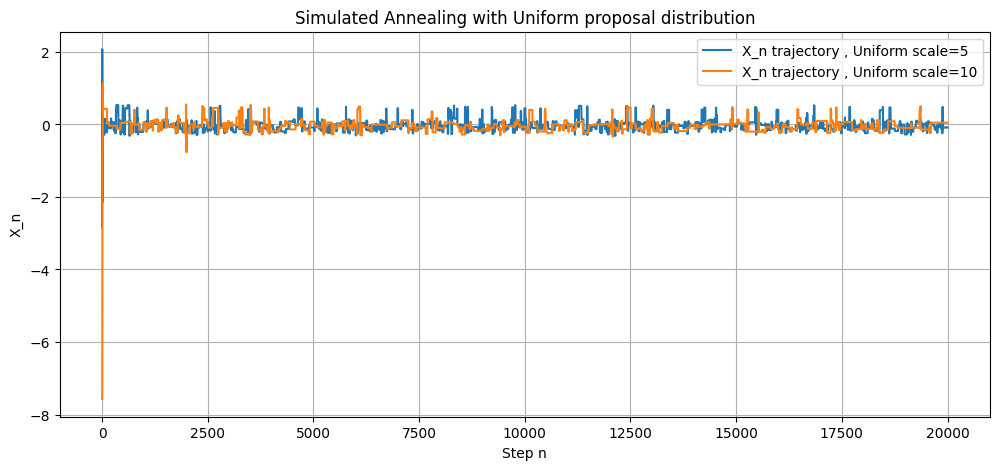

In [440]:
def step_uniform(scale):
    return np.random.uniform(-scale, scale)
proposal_scales = [5, 10]
plt.figure(figsize=(12,5))

for scale in proposal_scales:
    # Corrected line: Extract only the trajectory array from the returned tuple
    X_traj, _ = simulated_annealing(V, n_steps, step_uniform, scale)
    x_min = X_traj[-1]
    V_min = V(x_min)
    print(f"Uniform proposal scale: {scale}")
    print(f"Estimated global minimum: x \u2248 {x_min:.6f}, V(x) \u2248 {V_min:.6f}")
    plt.plot(np.arange(n_steps), X_traj, label=f"X_n trajectory , Uniform scale={scale}")

plt.xlabel("Step n")
plt.ylabel("X_n")
plt.title("Simulated Annealing with Uniform proposal distribution")
plt.grid(True)
plt.legend()
plt.show()


## **Q4. Graph coloring.**

### (a) **Let's draw a connected planar graph with 10 nodes (planar means no edge crossings) and enter its adjacency matrix.**

Adjacency matrix:
 [[0 1 0 0 0 1 0 0 0 0]
 [1 0 1 0 0 0 1 0 0 0]
 [0 1 0 1 0 0 0 1 0 0]
 [0 0 1 0 1 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 0 1 0 1 0 0]
 [0 0 1 0 0 0 1 0 1 0]
 [0 0 0 1 0 0 0 1 0 1]
 [0 0 0 0 1 0 0 0 1 0]]


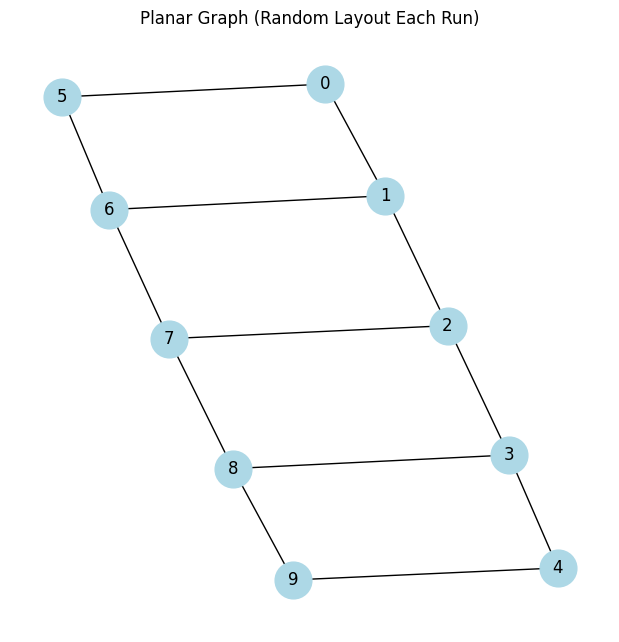

In [432]:

G = nx.grid_2d_graph(2, 5)
G = nx.convert_node_labels_to_integers(G)

adj_matrix = nx.to_numpy_array(G, dtype=int)
print("Adjacency matrix:\n", adj_matrix)

pos = nx.spring_layout(G)

plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_size=700, node_color="lightblue")
plt.title("Planar Graph (Random Layout Each Run)")
plt.show()


### **(b) Let's generate a vector of size 10 that contains random colors coded as 1, 2, 3, and 4.**

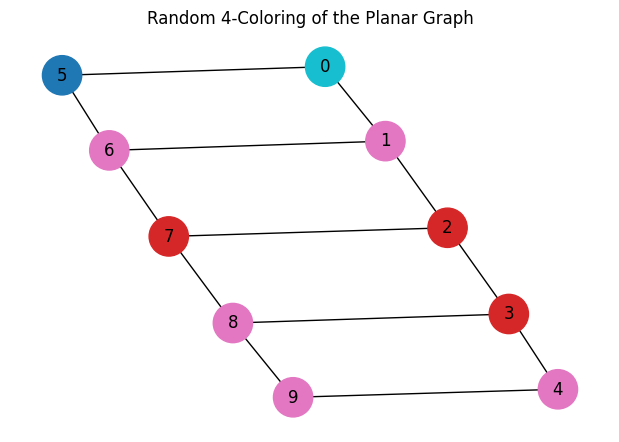

In [433]:

colors_init = np.random.randint(1, 5, size=10)
plt.figure(figsize=(6,4))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=colors_init,
    cmap=plt.cm.tab10,
    node_size=800
)
plt.title("Random 4-Coloring of the Planar Graph")
plt.show()


### **(c) Let's write a function for the cost of the problem.**

In [434]:
def cost_function(matrix, color_vector):
    n = matrix.shape[0]
    cost = 0
    for i in range(n):
        for j in range(i+1, n):
            if matrix[i, j] == 1 and color_vector[i] == color_vector[j]:
                cost += 1
    return cost

In [435]:
loss =  cost_function(adj_matrix, colors_init)
loss

5

### (d) Use simulated annealing to find an optimal coloring of the graph. Plot the resulting graph.

In [436]:
def simulated_annealing_coloring(adj_matrix, colors_init, n_steps=10000, n_colors=4):
    n_nodes = adj_matrix.shape[0]
    colors = colors_init
    cost = cost_function(adj_matrix, colors)

    best_colors = colors.copy()
    best_cost = cost
    accept = 0

    cost_history = [cost]
    for n in range(1, n_steps):
        beta = 1 + np.log(n)

        # propose new coloring
        node = np.random.randint(0, n_nodes)
        new_color = np.random.randint(1, n_colors+1)
        new_colors = colors.copy()
        new_colors[node] = new_color

        new_cost = cost_function(adj_matrix, new_colors)
        if cost == 0:
          break
        delta = new_cost - cost

        # Metropolis acceptance
        if np.random.rand() < min(1, np.exp(-beta * delta)):
            colors = new_colors
            cost = new_cost
            accept += 1

            if cost < best_cost:
                best_colors = colors.copy()
                best_cost = cost

        cost_history.append(cost)

    return best_colors, best_cost, accept/n_steps, cost_history

Best coloring found: [2 1 2 4 3 3 2 4 1 2]
Cost: 0
Acceptance rate: 0.0033


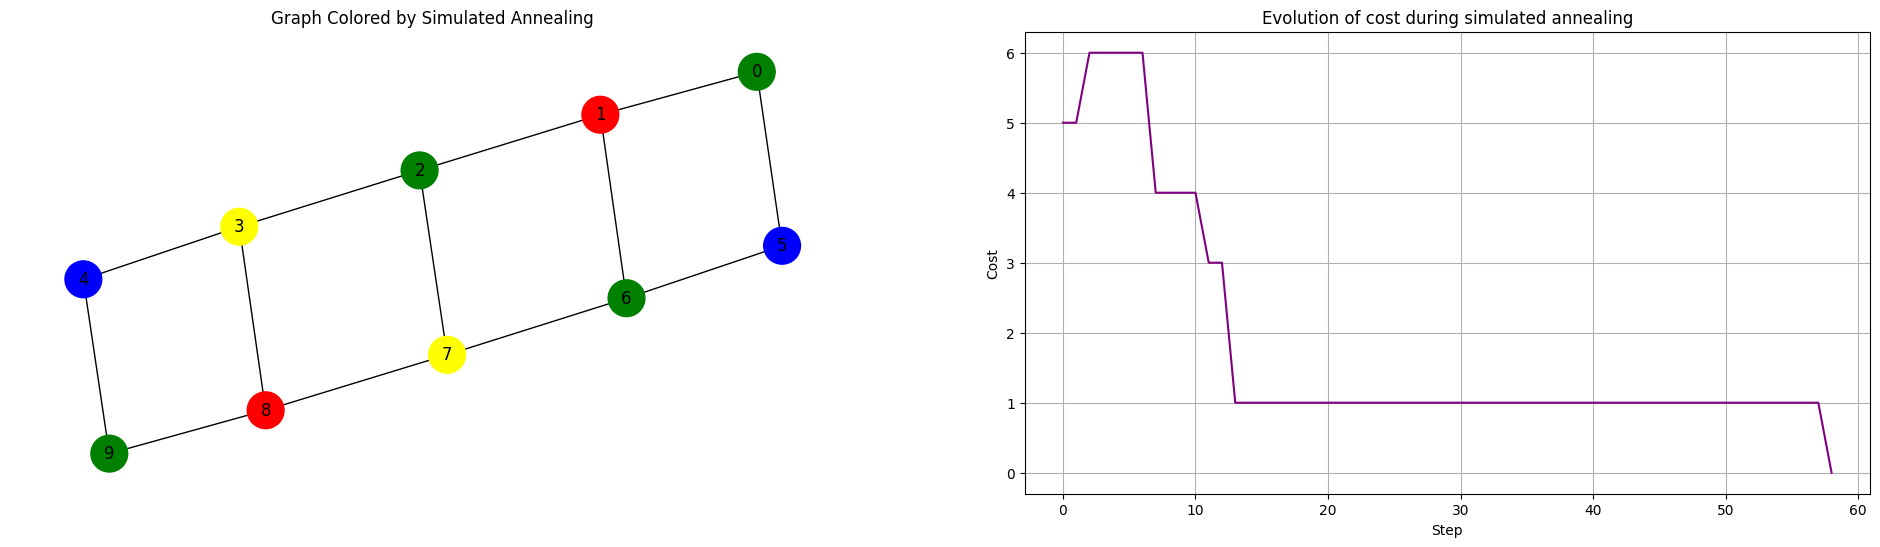

In [437]:
best_colors, best_cost, acceptance_rate, cost_history = simulated_annealing_coloring(adj_matrix, colors_init)
print("Best coloring found:", best_colors)
print("Cost:", best_cost)
print("Acceptance rate:", acceptance_rate)


color_map = {1:'red', 2:'green', 3:'blue', 4:'yellow'}
node_colors = [color_map[c] for c in best_colors]
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(24,6))
plt.subplot(1, 2, 1)
nx.draw(G, pos, with_labels=True, node_size=700, node_color=node_colors)
plt.title("Graph Colored by Simulated Annealing")
plt.subplot(1, 2, 2)

plt.plot(cost_history, color='purple')
plt.xlabel("Step")
plt.ylabel("Cost")
plt.title("Evolution of cost during simulated annealing")
plt.grid(True)
plt.show()

**Sources**

In [420]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html
# https://networkx.org/documentation
# Demos week 3